In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import sys
fh = 24
sys.path.append('../src')


df_raw = pd.read_csv('../data/raw/PJME_hourly.csv', parse_dates=['Datetime'], index_col='Datetime')
df_raw = df_raw.sort_index()
df_raw = df_raw.groupby(df_raw.index).mean() 
assert df_raw.index.is_unique
df_raw = df_raw.asfreq('h')

# Interpolación para los huecos de spring forward (son ~16 horas en 16 años)
print(f"NaNs por DST: {df_raw['PJME_MW'].isna().sum()}")
df_raw['PJME_MW'] = df_raw['PJME_MW'].interpolate(method='time')

# Verificación final
assert df_raw['PJME_MW'].isna().sum() == 0
assert df_raw.index.freq is not None
print("Dataset limpio y listo")

NaNs por DST: 30
Dataset limpio y listo


In [2]:
# Serie original sin shift
endog = np.log(df_raw['PJME_MW'])

# Proporciones
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
# TEST_RATIO  = 0.15 implícito

n         = len(endog)
train_end = int(n * TRAIN_RATIO)
val_end   = train_end + int(n * VAL_RATIO)

endog_train = endog.iloc[:train_end]
endog_val   = endog.iloc[train_end:val_end]
endog_test  = endog.iloc[val_end:]

# Verificar continuidad
assert (endog_val.index[0] - endog_train.index[-1])  == pd.Timedelta('1h'), "Gap train→val"
assert (endog_test.index[0] - endog_val.index[-1])   == pd.Timedelta('1h'), "Gap val→test"

# Resumen
print(f"Total observaciones: {n:,}")
print(f"\n{'Set':<10} {'Start':<25} {'End':<25} {'Samples':>10} {'%':>6}")
print("-" * 80)
for name, s in [('Train', endog_train), ('Val', endog_val), ('Test', endog_test)]:
    print(f"{name:<10} {str(s.index[0]):<25} {str(s.index[-1]):<25} {len(s):>10,} {len(s)/n*100:>5.1f}%")

Total observaciones: 145,392

Set        Start                     End                          Samples      %
--------------------------------------------------------------------------------
Train      2002-01-01 01:00:00       2013-08-11 14:00:00          101,774  70.0%
Val        2013-08-11 15:00:00       2016-02-06 06:00:00           21,808  15.0%
Test       2016-02-06 07:00:00       2018-08-03 00:00:00           21,810  15.0%


In [3]:
# =============================================================================
# MÉTRICAS
# =============================================================================

def evaluate(y_true, y_pred, split_name=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\nMétricas [{split_name}]")
    print(f"  MAE  : {mae:,.1f} MW")
    print(f"  RMSE : {rmse:,.1f} MW")
    print(f"  MAPE : {mape:.2f}%")
    return {'mae': mae, 'rmse': rmse, 'mape': mape}



# =============================================================================
# VISUALIZACIÓN — muestra una semana para que sea legible
# =============================================================================

def plot_forecast(y_true, y_pred, title, n_days=7):
    n = n_days * 24
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # Plot 1: primeros n_days
    axes[0].plot(y_true.index[:n], y_true.values[:n], label='Real',       color='steelblue')
    axes[0].plot(y_pred.index[:n], y_pred.values[:n], label='Predicción', color='tomato', linestyle='--')
    axes[0].set_title(f'{title} — primeros {n_days} días')
    axes[0].legend()
    axes[0].set_ylabel('MW')

    # Plot 2: error absoluto
    error = np.abs(y_true.values[:n] - y_pred.values[:n])
    axes[1].fill_between(y_true.index[:n], error, alpha=0.5, color='tomato')
    axes[1].set_title('Error absoluto (MW)')
    axes[1].set_ylabel('MW')

    plt.tight_layout()
    plt.show()

In [ ]:
# # Entrenás con train
# model = SARIMAX(endog_train, order=(1,1,1), seasonal_order=(1,0,1,24), trend='n')
# result = model.fit(disp=False, cov_type='none')


In [ ]:
models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

model_path = models_dir / 'sarimax_24.pkl'


In [ ]:
# # Guardar
# result.save(models_dir / 'sarimax_24.pkl', remove_data=True)
# print(f"Modelo guardado en {model_path}")


Modelo guardado en ..\models\sarimax_24.pkl


In [16]:
# Cargar
from statsmodels.tsa.statespace.sarimax import SARIMAXResultsWrapper
result = SARIMAXResultsWrapper.load(models_dir / 'sarimax_24.pkl')


Métricas [Validación]
  MAE  : 217.6 MW
  RMSE : 303.8 MW
  MAPE : 0.71%


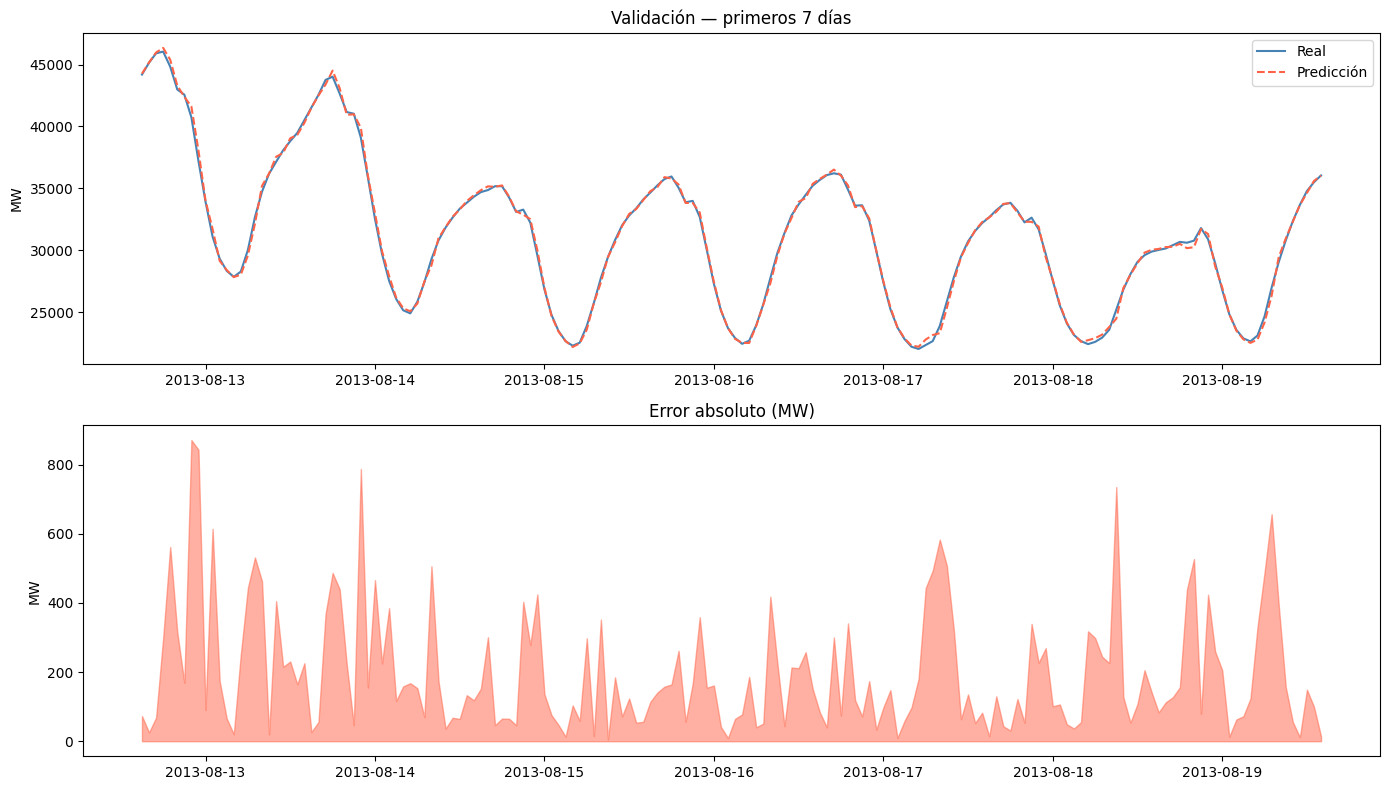

In [21]:
# # get_forecast genera predicciones out-of-sample paso a paso
# forecast_val = result.get_forecast(steps=len(endog_val))
# pred_val_log = forecast_val.predicted_mean

result_val    = result.apply(endog_val)   # no sobreescribir result_full
pred_val_log  = result_val.fittedvalues
pred_val      = np.exp(pred_val_log)
real_val      = np.exp(endog_val)

warmup = 24
metrics_val = evaluate(real_val.iloc[warmup:], pred_val.iloc[warmup:], 'Validación')
plot_forecast(real_val.iloc[warmup:], pred_val.iloc[warmup:], 'Validación')


Métricas [Test (sin warmup)]
  MAE  : 212.1 MW
  RMSE : 292.2 MW
  MAPE : 0.70%


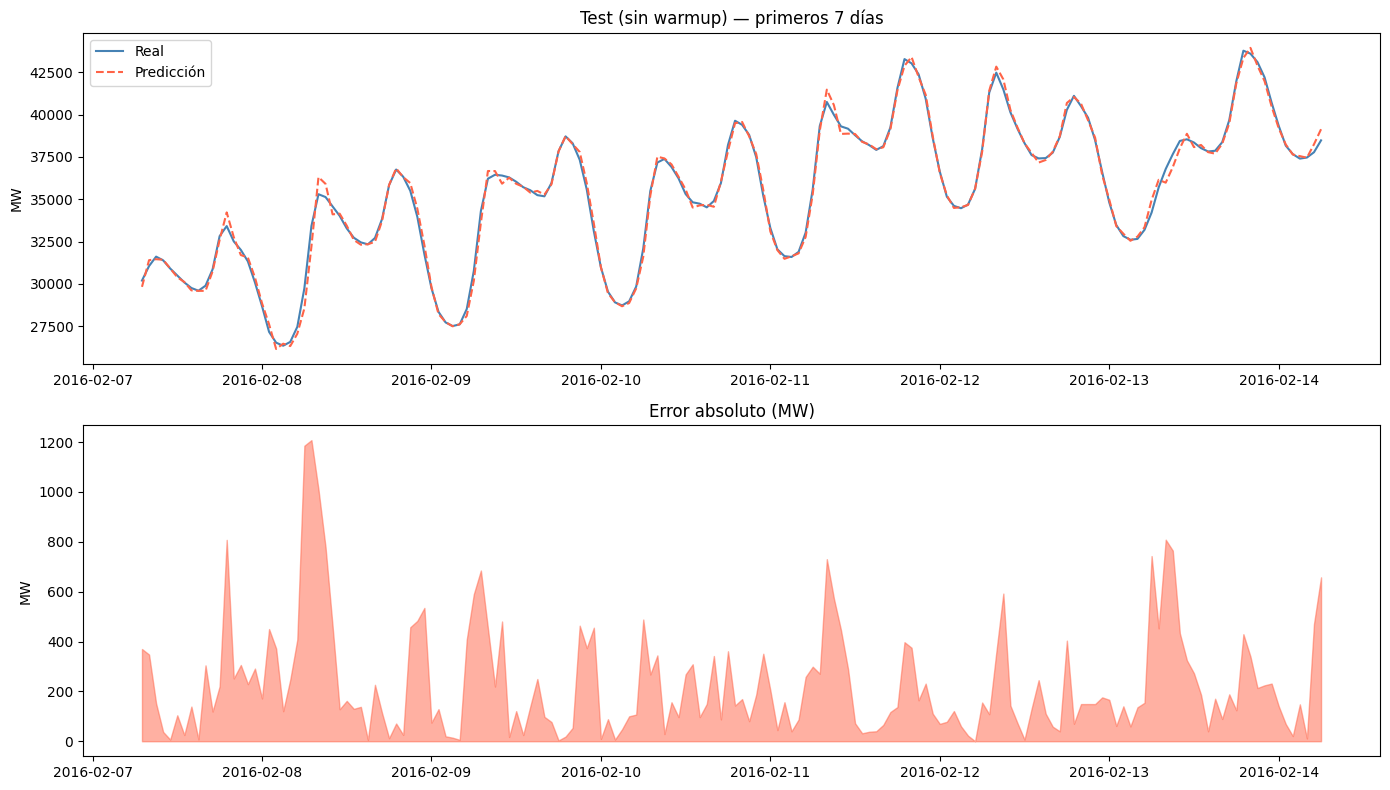

In [10]:
# Evaluación sobre test completo (igual que validación)
result_test = result.apply(endog_test)
pred_test_log = result_test.fittedvalues

pred_test = np.exp(pred_test_log)
real_test = np.exp(endog_test)

assert (real_test.index == pred_test.index).all()

warmup = 24
metrics_test = evaluate(real_test.iloc[warmup:], pred_test.iloc[warmup:], 'Test (sin warmup)')
plot_forecast(real_test.iloc[warmup:], pred_test.iloc[warmup:], 'Test (sin warmup)')

In [19]:
result_updated = result.apply(endog_train.iloc[-48:])
forecast = result_updated.get_forecast(steps=24)

pred_log = forecast.predicted_mean          # predicciones en escala log
ci_log   = forecast.conf_int(alpha=0.05)    # intervalo de confianza 95%

pred_mw  = np.exp(pred_log)                 # volver a MW
ci_mw    = np.exp(ci_log)                   # IC en MW

print(pred_mw)

2013-08-11 15:00:00    36905.692195
2013-08-11 16:00:00    37642.035245
2013-08-11 17:00:00    38109.518737
2013-08-11 18:00:00    38172.047260
2013-08-11 19:00:00    37539.013165
2013-08-11 20:00:00    36393.464232
2013-08-11 21:00:00    36046.243614
2013-08-11 22:00:00    35175.253147
2013-08-11 23:00:00    33361.366511
2013-08-12 00:00:00    31290.613032
2013-08-12 01:00:00    29380.864635
2013-08-12 02:00:00    27896.047878
2013-08-12 03:00:00    26888.860651
2013-08-12 04:00:00    26152.368679
2013-08-12 05:00:00    25755.023359
2013-08-12 06:00:00    25715.786324
2013-08-12 07:00:00    25739.208287
2013-08-12 08:00:00    26672.143003
2013-08-12 09:00:00    28313.005824
2013-08-12 10:00:00    29929.106070
2013-08-12 11:00:00    31225.198904
2013-08-12 12:00:00    32384.860684
2013-08-12 13:00:00    33177.192362
2013-08-12 14:00:00    33844.049256
Freq: h, Name: predicted_mean, dtype: float64


In [ ]:
# # Flujo típico en producción
# # 1. Cargar modelo guardado
# result_full = SARIMAXResultsWrapper.load(models_dir / 'sarimax_24.pkl')

# # 2. Si llegaron datos nuevos desde que entrenaste, extender el modelo
# result_updated = result_full.apply(nuevos_datos_log)

# # 3. Predecir las próximas 24 horas desde el último dato conocido
# forecast = result_updated.get_forecast(steps=24)
# pred_mw  = np.exp(forecast.predicted_mean)

# print(f"Predicción próximas 24h:")
# print(pred_mw)